In [1]:
import os
import diopy
import numpy as np
import pandas as pd
import scanpy as sc 
import anndata as ad
import scanpy.external as sce
import matplotlib.pyplot as plt
import cosg

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/umap/d

scanpy==1.9.3 anndata==0.9.1 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.2.2 statsmodels==0.14.0 python-igraph==0.10.4 pynndescent==0.5.10


/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/umap/umap_.py:660: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()


In [3]:
adata = diopy.input.read_h5(file = '/bigdata/zlin/Melanoma_meta/data/HNSC_IMCISION/seu.h5')
adata.X = adata.layers['counts'].copy()
adata

AnnData object with n_obs × n_vars = 30835 × 14939
    obs: 'orig.ident', 'cell_id', 'seq_run', 'new_hash_ID', 'UMIA.CD56', 'rcA_AC_CD56', 'patient', 'timepoint', 'response', 'pat_clone_ID', 'mc', 'mc_group', 'cell_type', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'celltype_bped_main', 'celltype_bped_fine', 'immune'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    layers: 'counts'

In [4]:
# # ribosomal genes.
# adata.var['ribo'] = adata.var_names.str.startswith(("RPS","RPL"))
# # hemoglobin genes.
# adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P)]"))
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
# filter genes
sc.pp.filter_genes(adata, min_cells=20)

filtered out 575 genes that are detected in less than 20 cells


In [5]:
adata_counts = adata.copy()

In [6]:
noise = pd.read_excel("/bigdata/zlin/Melanoma_meta/data/41586_2022_5400_MOESM3_ESM.xlsx", sheet_name="1d_Genes excluded", index_col=0, header = 2)
noise = noise.to_numpy().flatten()
noise = noise[~pd.isnull(noise)]
noise = np.append(noise, "MALAT1")

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata

normalizing counts per cell


    finished (0:00:00)


In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, layer='counts', flavor='seurat_v3', subset=True)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [9]:
adata = adata[:,np.setdiff1d(adata.var_names.values, noise)]
adata

View of AnnData object with n_obs × n_vars = 30835 × 1970
    obs: 'orig.ident', 'cell_id', 'seq_run', 'new_hash_ID', 'UMIA.CD56', 'rcA_AC_CD56', 'patient', 'timepoint', 'response', 'pat_clone_ID', 'mc', 'mc_group', 'cell_type', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'celltype_bped_main', 'celltype_bped_fine', 'immune', 'n_genes_by_counts', 'total_counts'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [10]:
sc.pp.regress_out(adata, ['total_counts','S.Score','G2M.Score'])
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, svd_solver='arpack')
sce.pp.bbknn(adata, batch_key='sample')
# sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')
sc.tl.leiden(adata, resolution=1, key_added='leiden_1')

regressing out ['total_counts', 'S.Score', 'G2M.Score']
    sparse input is densified and may lead to high memory use
    finished (0:00:46)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:03)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:16)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:39)
running Leiden clustering
    finished: found 15 clusters and added
    'leiden_0.5', the cluster labels (adata.obs, categorical) (0:00:19)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden_1', the cluster labels (adata.obs, categorical) (0:00:29)


/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


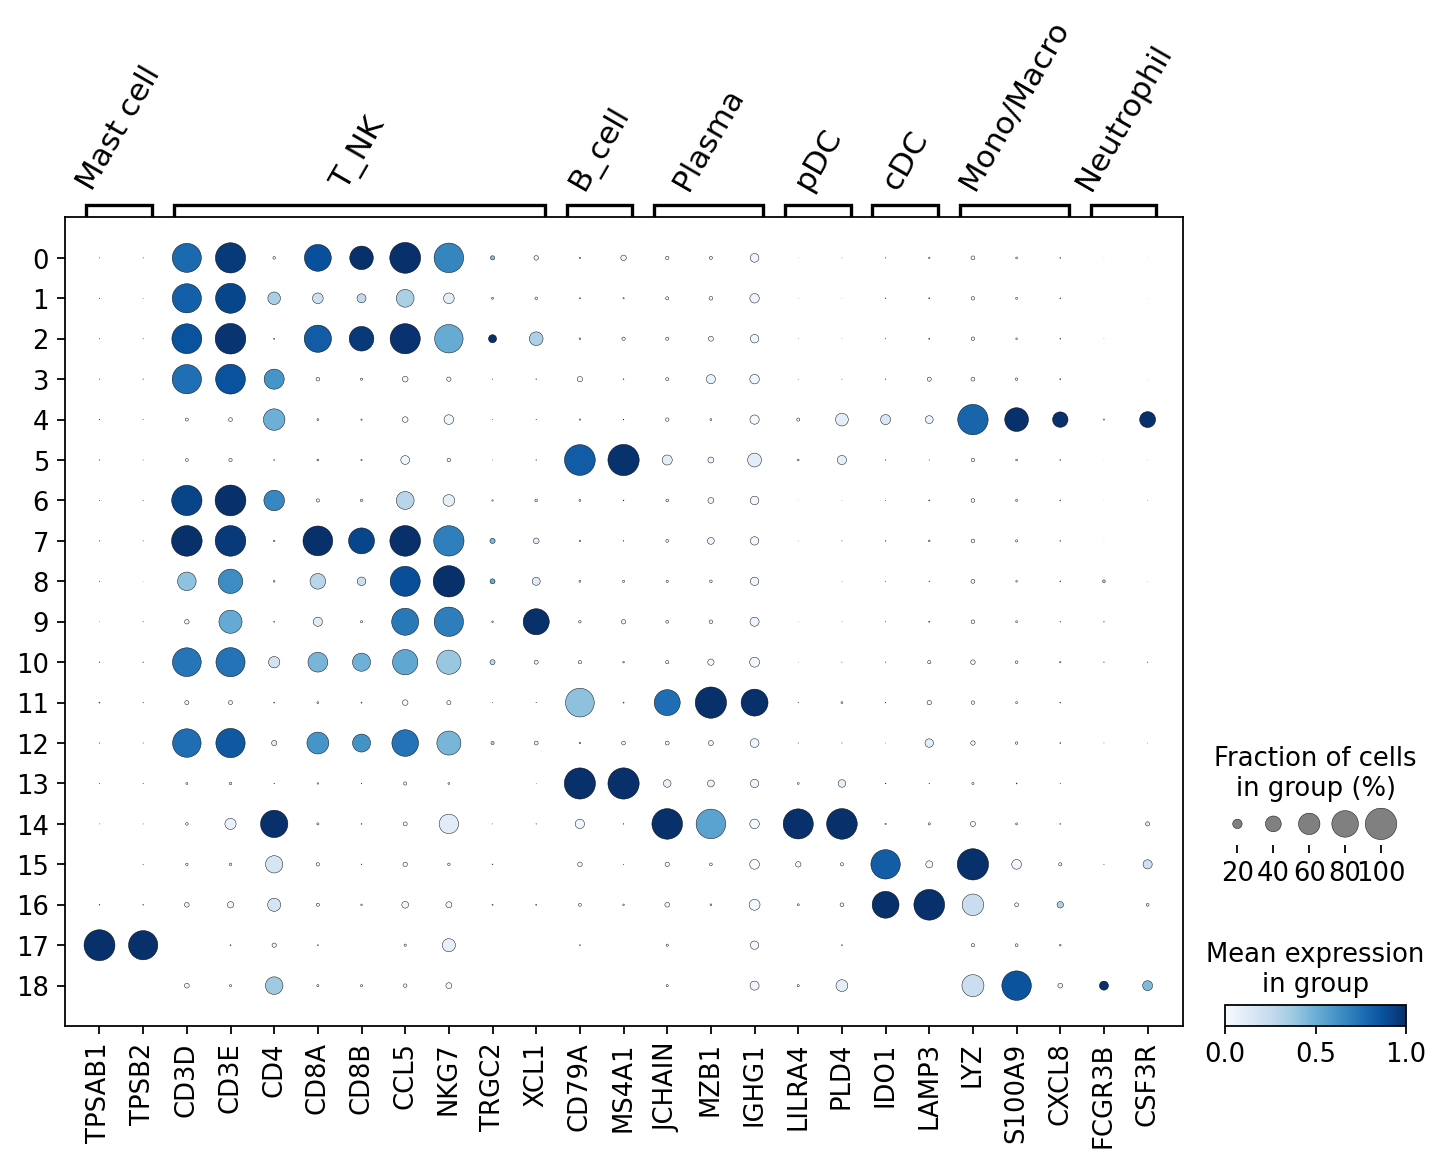

In [11]:
# check markers
marker_genes_dict = {
    'Mast cell':['TPSAB1','TPSB2'],
    'T_NK': ['CD3D','CD3E','CD4','CD8A','CD8B','CCL5','NKG7','TRGC2','XCL1'],
    'B_cell':['CD79A','MS4A1'],
    'Plasma':['JCHAIN','MZB1','IGHG1'],
    'pDC':['LILRA4','PLD4'],
    'cDC':['IDO1','LAMP3'],
    'Mono/Macro':['LYZ','S100A9','CXCL8'],
    'Neutrophil':['FCGR3B', 'CSF3R']
}
sc.pl.dotplot(adata, marker_genes_dict, 'leiden_1',cmap='Blues',var_group_rotation=60, standard_scale='var')

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


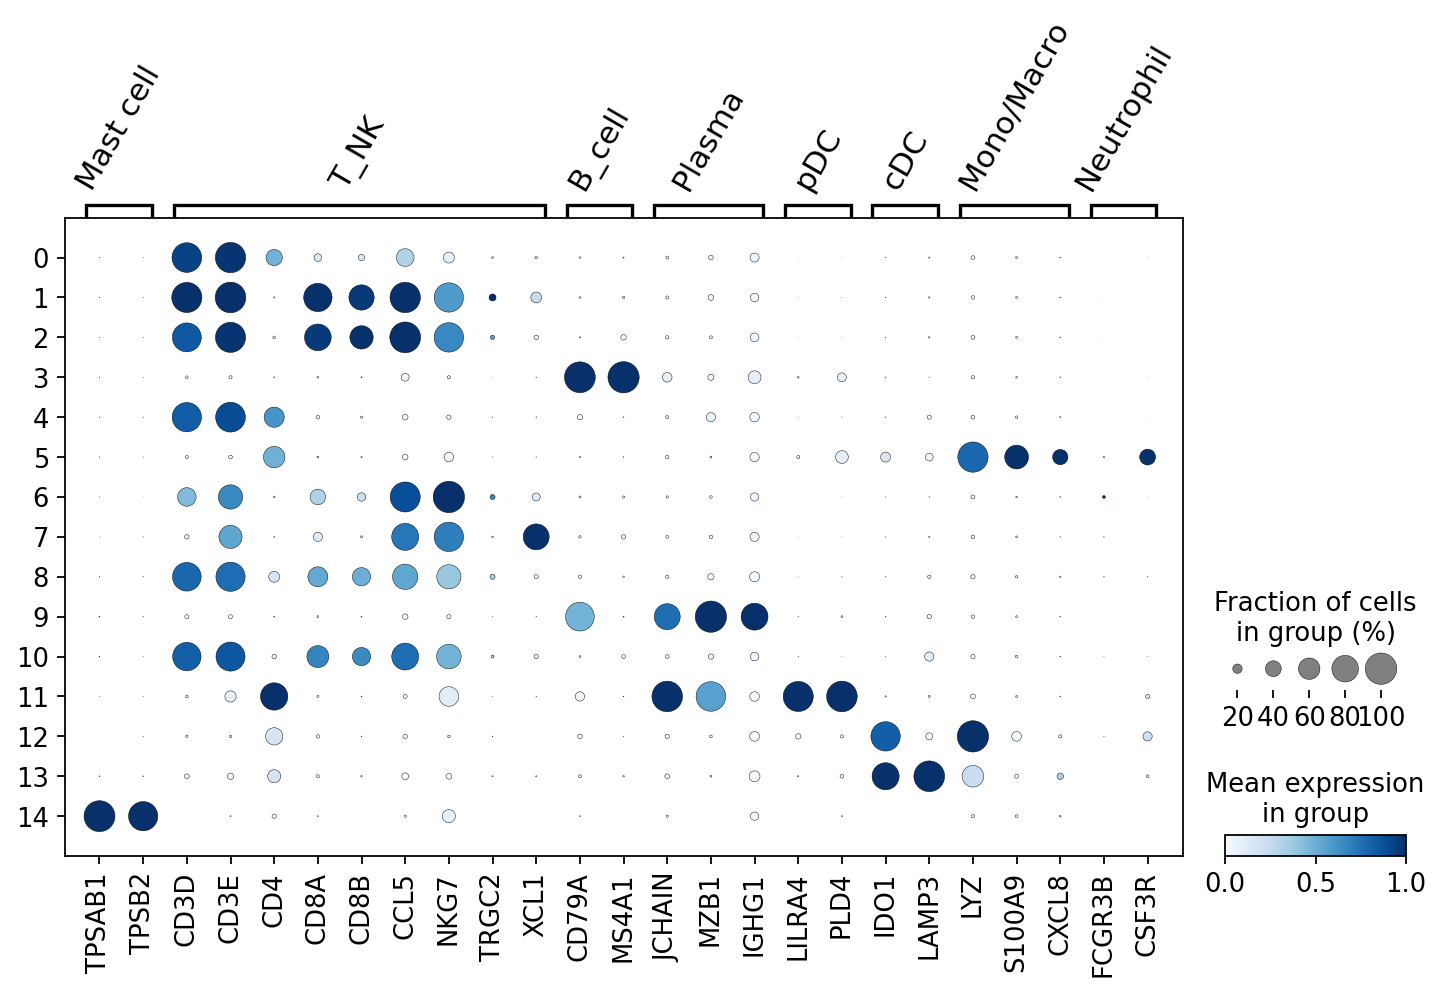

In [48]:
sc.pl.dotplot(adata, marker_genes_dict, 'leiden_0.5',cmap='Blues',var_group_rotation=60, standard_scale='var')

In [12]:
n_gene=30
groupby='leiden_1'
cosg.cosg(adata,
    key_added='cosg',
    # use_raw=False, layer='log1p', ## e.g., if you want to use the log1p layer in adata
    mu=100,
    expressed_pct=0.1,
    remove_lowly_expressed=True,
    n_genes_user=100,
    groupby=groupby)

**finished identifying marker genes by COSG**


In [13]:
marker_gene=pd.DataFrame(adata.uns['cosg']['names'])
marker_gene.head()

,0,1,10,11,12,13,14,15,16,17,18,2,3,4,5,6,7,8,9
0,GZMK,IL22,TYMS,SDC1,IFIT1,IGHD,CLEC4C,CLEC9A,LAD1,TPSAB1,CDKN1C,ZNF683,FOXP3,CD14,TNFRSF13B,IL21,LRRN3,FGFBP2,SPTSSB
1,DKK3,RORC,ASPM,PDK1,RSAD2,FCER2,LILRA4,XCR1,CCL19,TPSB2,GPBAR1,TRDV1,IL2RA,S100A9,LINC01781,BHLHE40-AS1,TNFSF4,S1PR5,ADGRG3
2,EOMES,PASK,MKI67,IGHGP,CMPK2,AL139020.1,MAP1A,C1orf54,FSCN1,CPA3,SMIM25,LINC02446,CCR8,S100A8,SSPN,NMB,VCAM1,SPON2,TRDC
3,KLRG1,CD40LG,CENPF,IGHG1,IFIT3,CD72,TPM2,RAB7B,AOC1,HPGDS,CKB,TRGV4,RTKN2,IL1B,CD24,IGFL2,GPR25,PRSS23,KRT81
4,ITM2C,AQP3,CLSPN,LINC02362,USP18,TCL1A,LAMP5,CCND1,LIMCH1,SLC18A2,ICAM4,TRGV8,FANK1,VCAN,BANK1,CXCL13,PDLIM4,CX3CR1,XCL2


/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


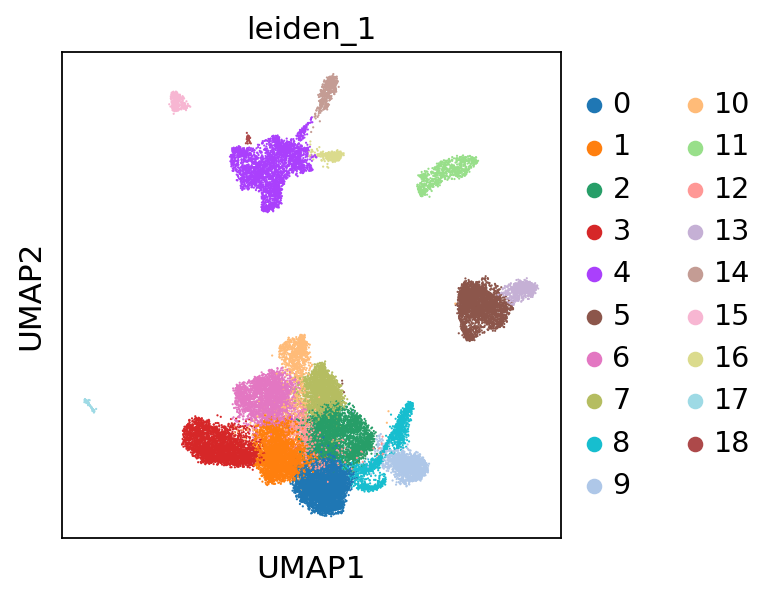

In [22]:
sc.pl.umap(adata, color=['leiden_1'])

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


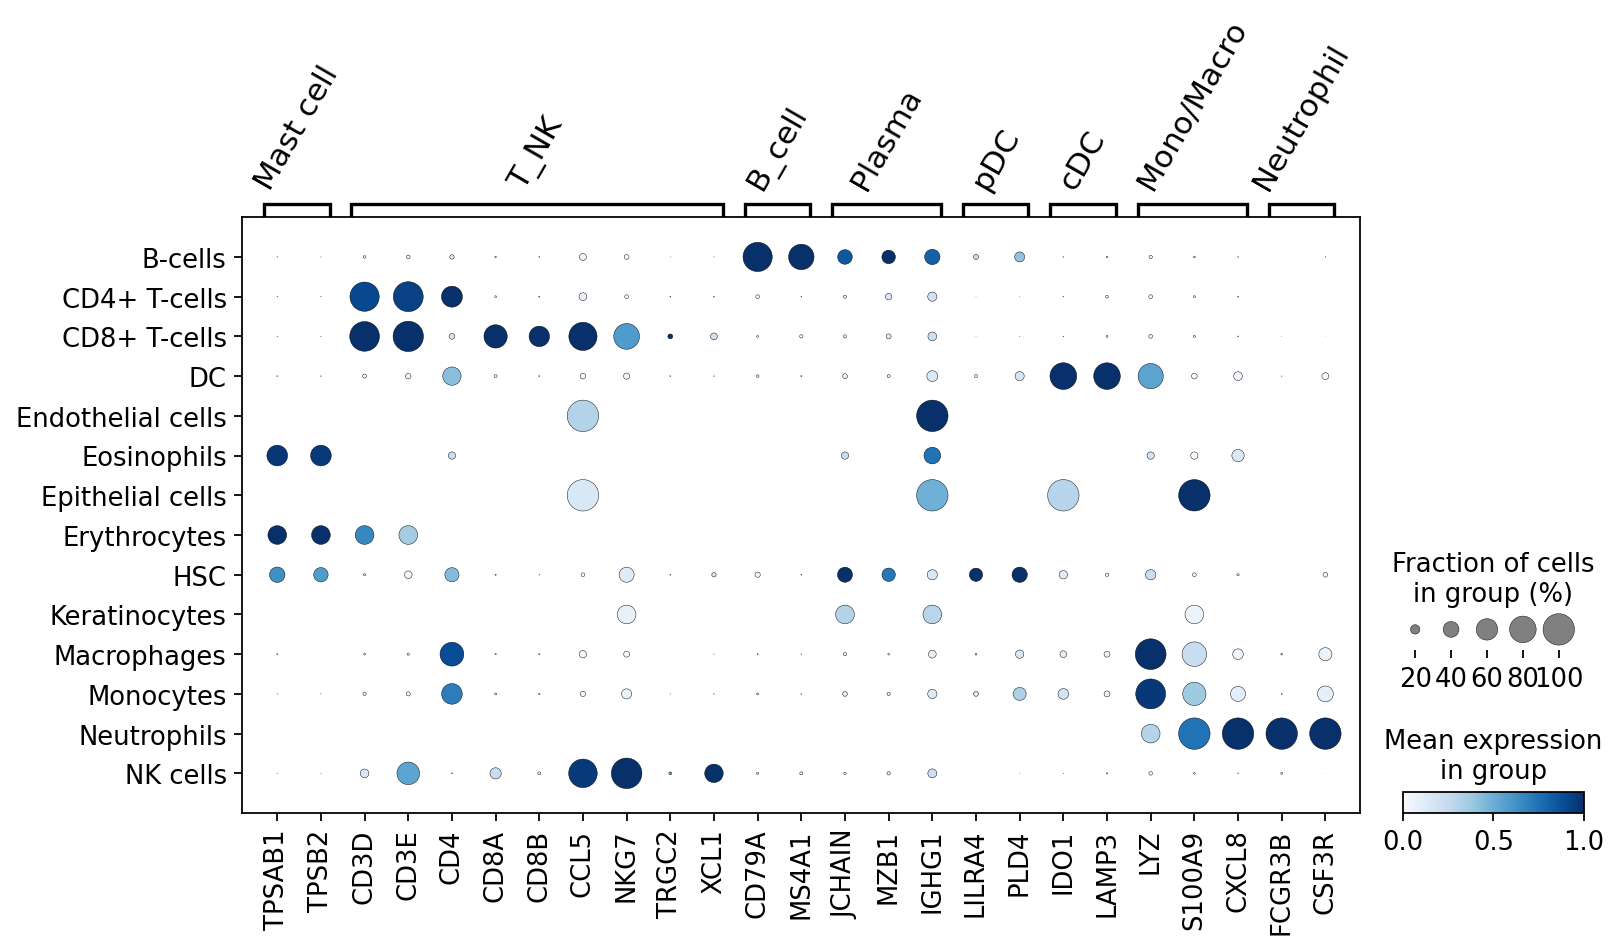

In [12]:
sc.pl.dotplot(adata, marker_genes_dict, 'celltype_bped_main',cmap='Blues',var_group_rotation=60, standard_scale='var')

In [14]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.crosstab(adata.obs['leiden_1'],adata.obs['celltype_bped_main'])

celltype_bped_main,B-cells,CD4+ T-cells,CD8+ T-cells,DC,Endothelial cells,Eosinophils,Epithelial cells,Erythrocytes,HSC,Keratinocytes,Macrophages,Monocytes,Neutrophils,NK cells
leiden_1,,,,,,,,,,,,,,
0,0,20,4123,0,0,0,0,0,0,0,0,0,0,19
1,0,1438,1927,0,0,1,0,0,1,1,1,0,0,2
2,0,6,3031,0,0,0,0,0,0,0,0,0,0,66
3,1,2263,648,1,0,0,0,0,0,0,0,0,0,0
4,0,0,1,155,0,0,0,0,16,0,399,2271,2,1
5,2619,1,19,1,0,0,0,0,0,0,0,1,0,3
6,0,1284,1256,0,0,0,0,0,0,0,0,0,0,8
7,0,5,2026,0,0,0,0,0,0,0,0,0,0,13
8,0,0,497,0,0,0,0,0,0,0,0,1,0,967


In [15]:
pd.crosstab(adata.obs['leiden_1'],adata.obs['celltype_bped_fine'])

celltype_bped_fine,CD4+ T-cells,CD4+ Tcm,CD4+ Tem,CD8+ T-cells,CD8+ Tcm,CD8+ Tem,Class-switched memory B-cells,CLP,CMP,DC,Eosinophils,Epithelial cells,Erythrocytes,GMP,Keratinocytes,Macrophages,Macrophages M1,Memory B-cells,MEP,Monocytes,MPP,mv Endothelial cells,naive B-cells,Neutrophils,NK cells,Plasma cells,Tregs
leiden_1,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,1,56,1,2506,1562,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,29
1,47,315,1305,7,602,340,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,3,0,754
2,0,5,37,16,1828,1171,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,39,0,6
3,2,7,8,0,5,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2891
4,0,0,0,0,0,0,0,2,0,167,0,0,2,5,0,476,2,0,0,2185,0,0,0,2,0,0,4
5,0,0,1,0,11,8,1870,0,0,0,0,0,0,0,0,0,0,663,0,1,0,0,64,0,2,13,4
6,3,138,974,0,89,203,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1144
7,1,0,21,0,860,1131,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,21
8,0,1,1,0,198,433,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,831,0,0


In [16]:
# annotate cells
adata.obs['celltype_major'] = 'Unassigned'
adata.obs.loc[adata.obs["leiden_0.5"].isin(["0","1","2","4","6","8","10"]), "celltype_major"] = "T_cells"
adata.obs.loc[adata.obs["leiden_1"].isin(["4","15","16","18"]), "celltype_major"] = "Myeloids"
adata.obs.loc[adata.obs["leiden_1"].isin(["5","13"]), "celltype_major"] = "B_cells"
adata.obs.loc[adata.obs["leiden_1"].isin(["11"]), "celltype_major"] = "Plasma"
adata.obs.loc[adata.obs["leiden_1"].isin(["14"]), "celltype_major"] = "pDC"
adata.obs.loc[adata.obs["leiden_1"].isin(["17"]), "celltype_major"] = "Mast"
adata.obs.loc[adata.obs["celltype_bped_main"].isin(["NK cells"]), "celltype_major"] = "NK_cells"
adata.obs.loc[adata.obs["leiden_1"].isin(["9"]), "celltype_major"] = "NK_cells"
adata.obs.loc[adata.obs["celltype_bped_main"].isin(["Neutrophils"]), "celltype_major"] = "Neutrophils"

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


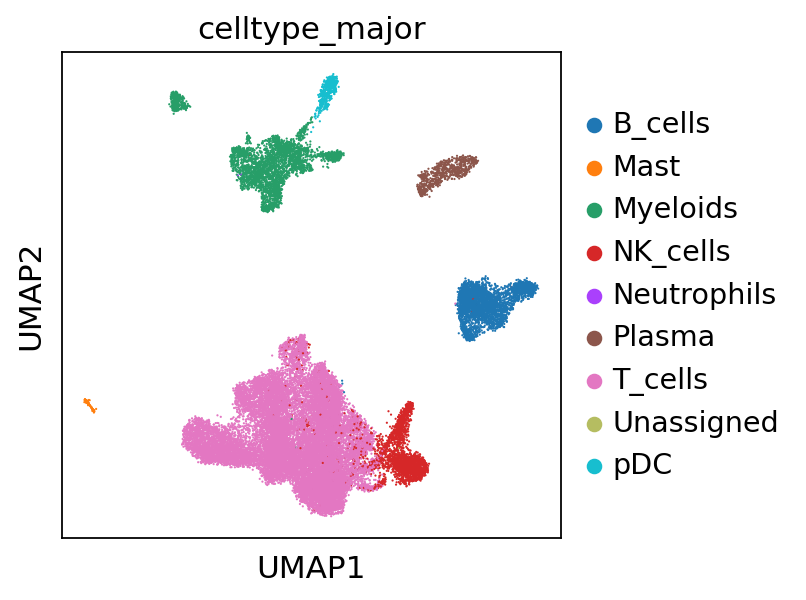

In [18]:
sc.pl.umap(adata, color='celltype_major')

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


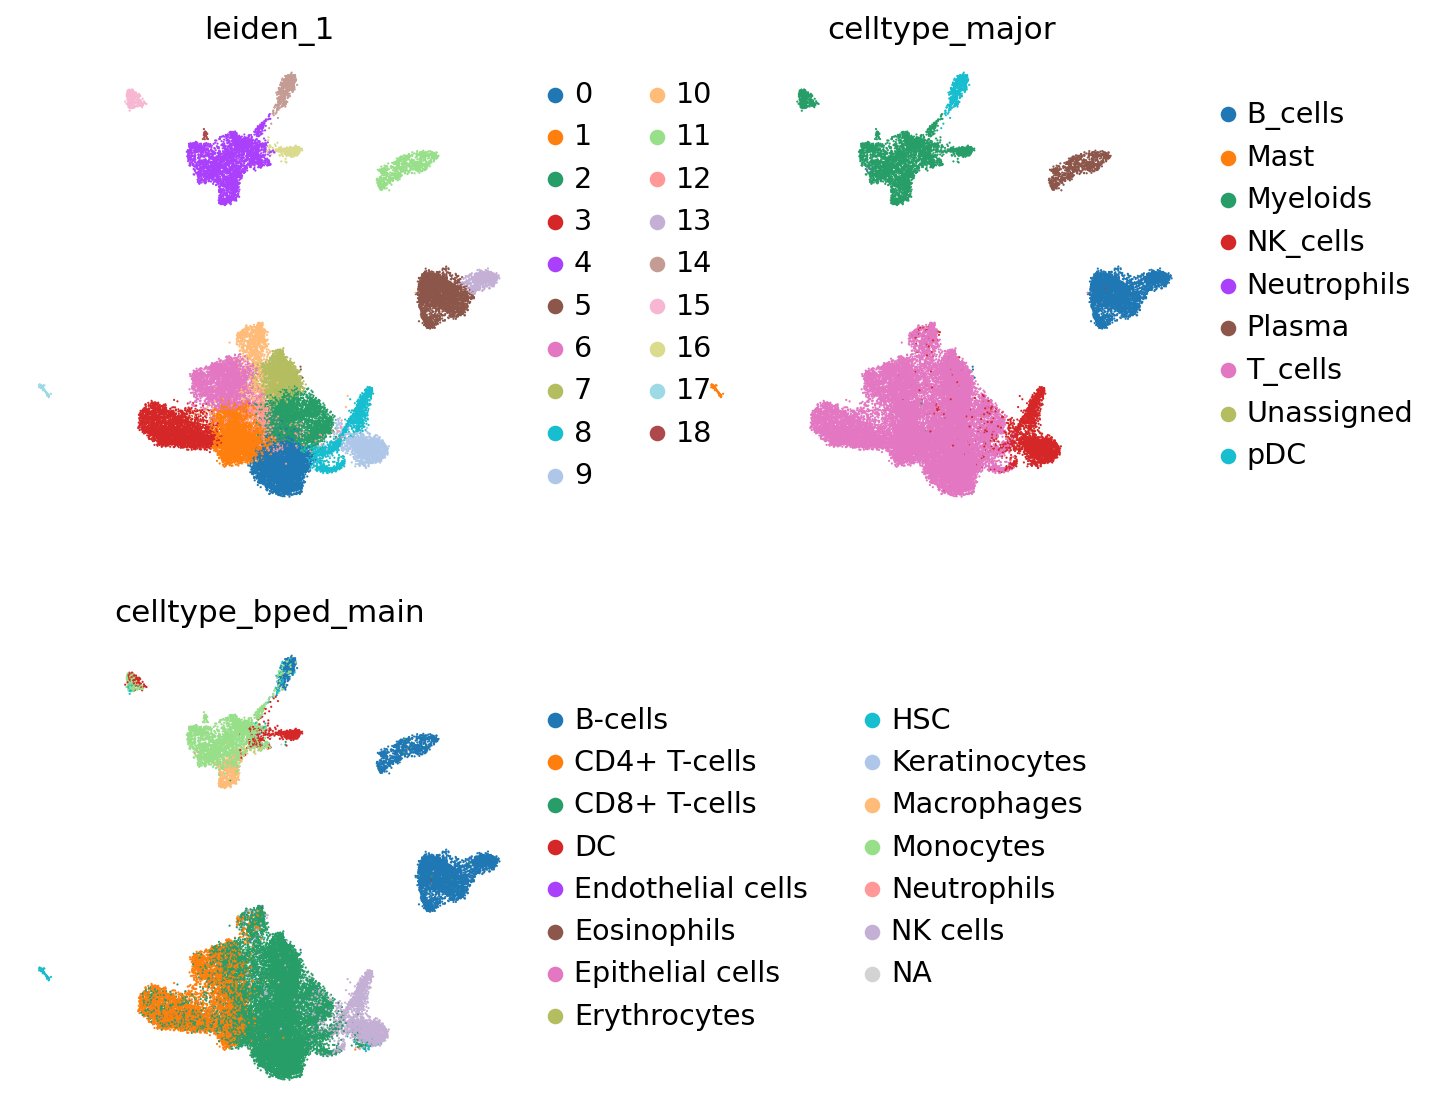

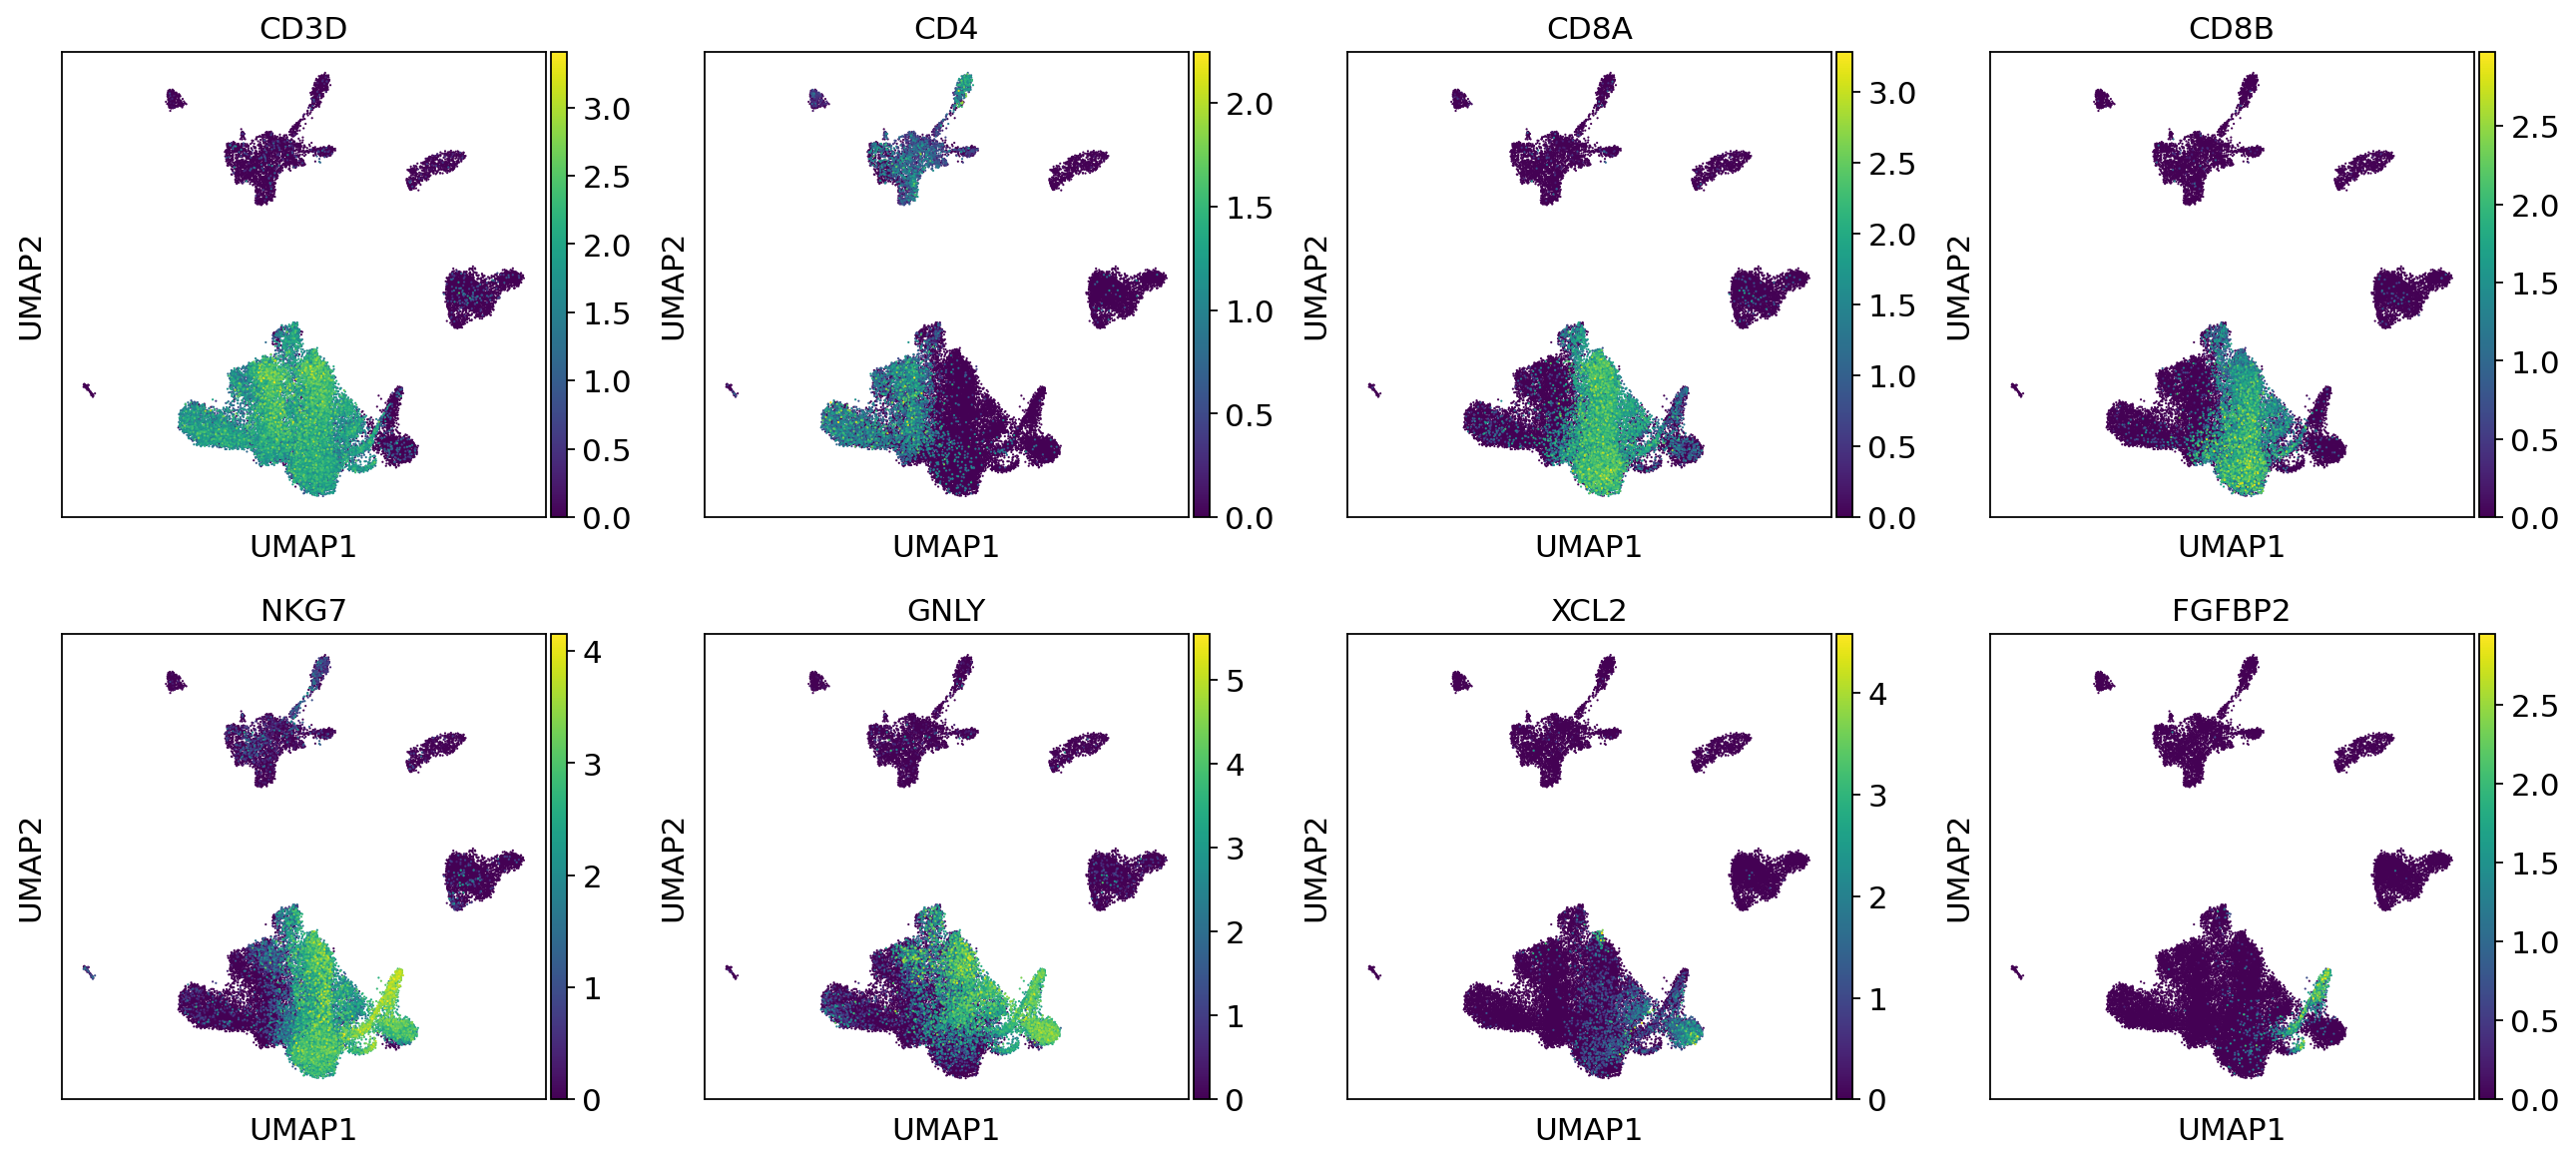

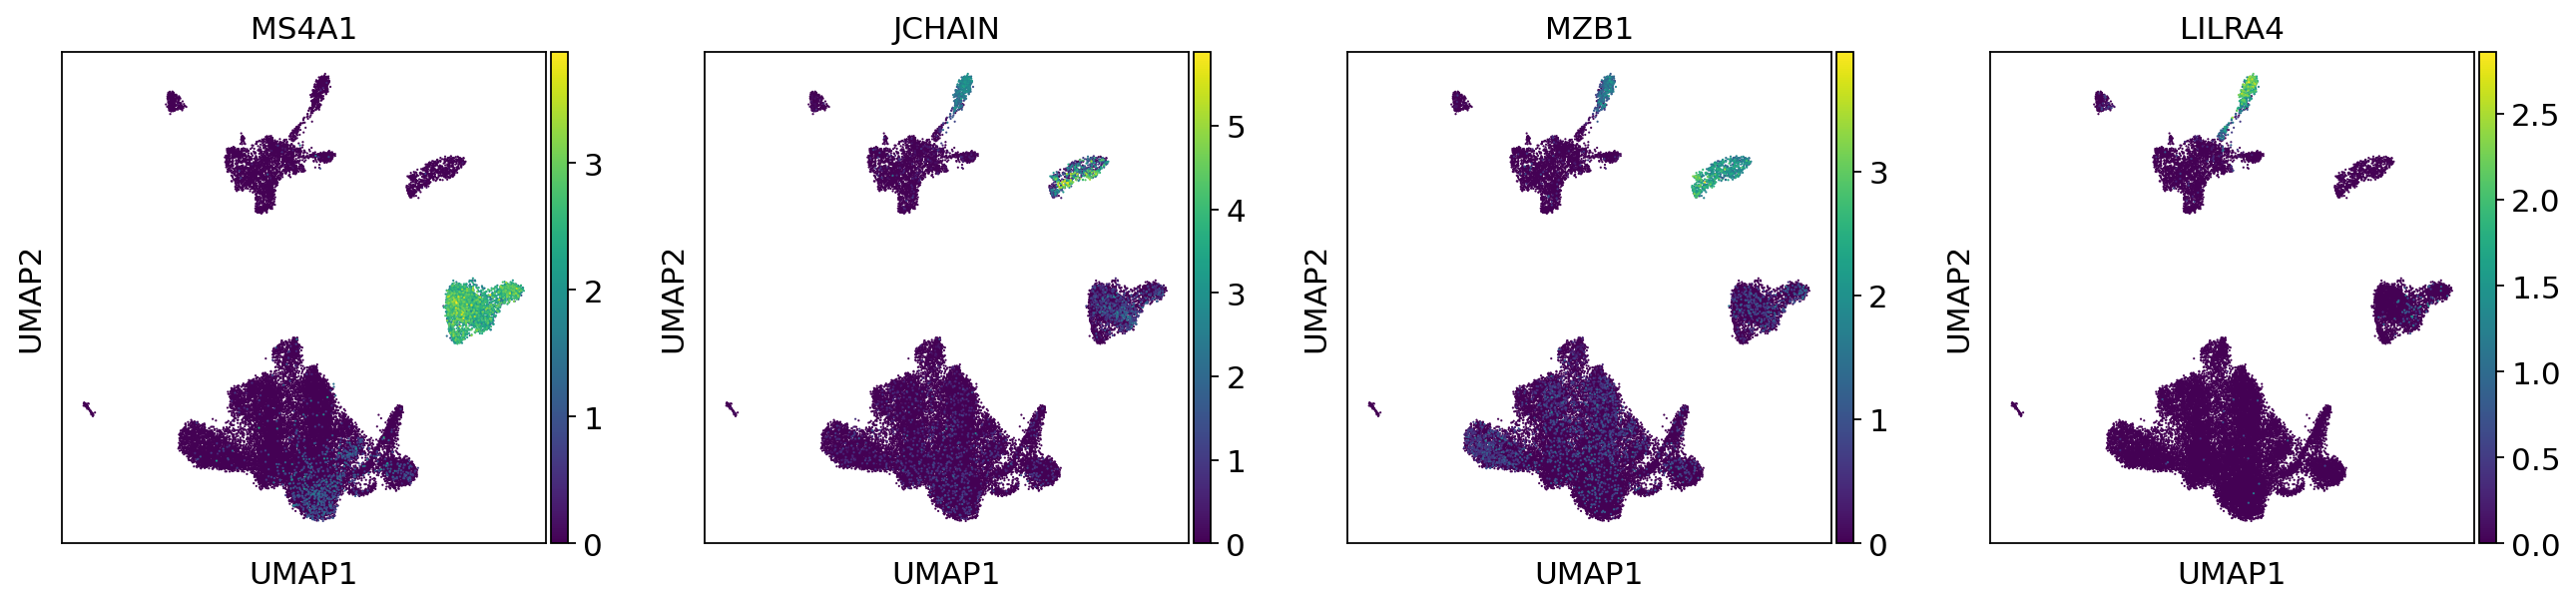

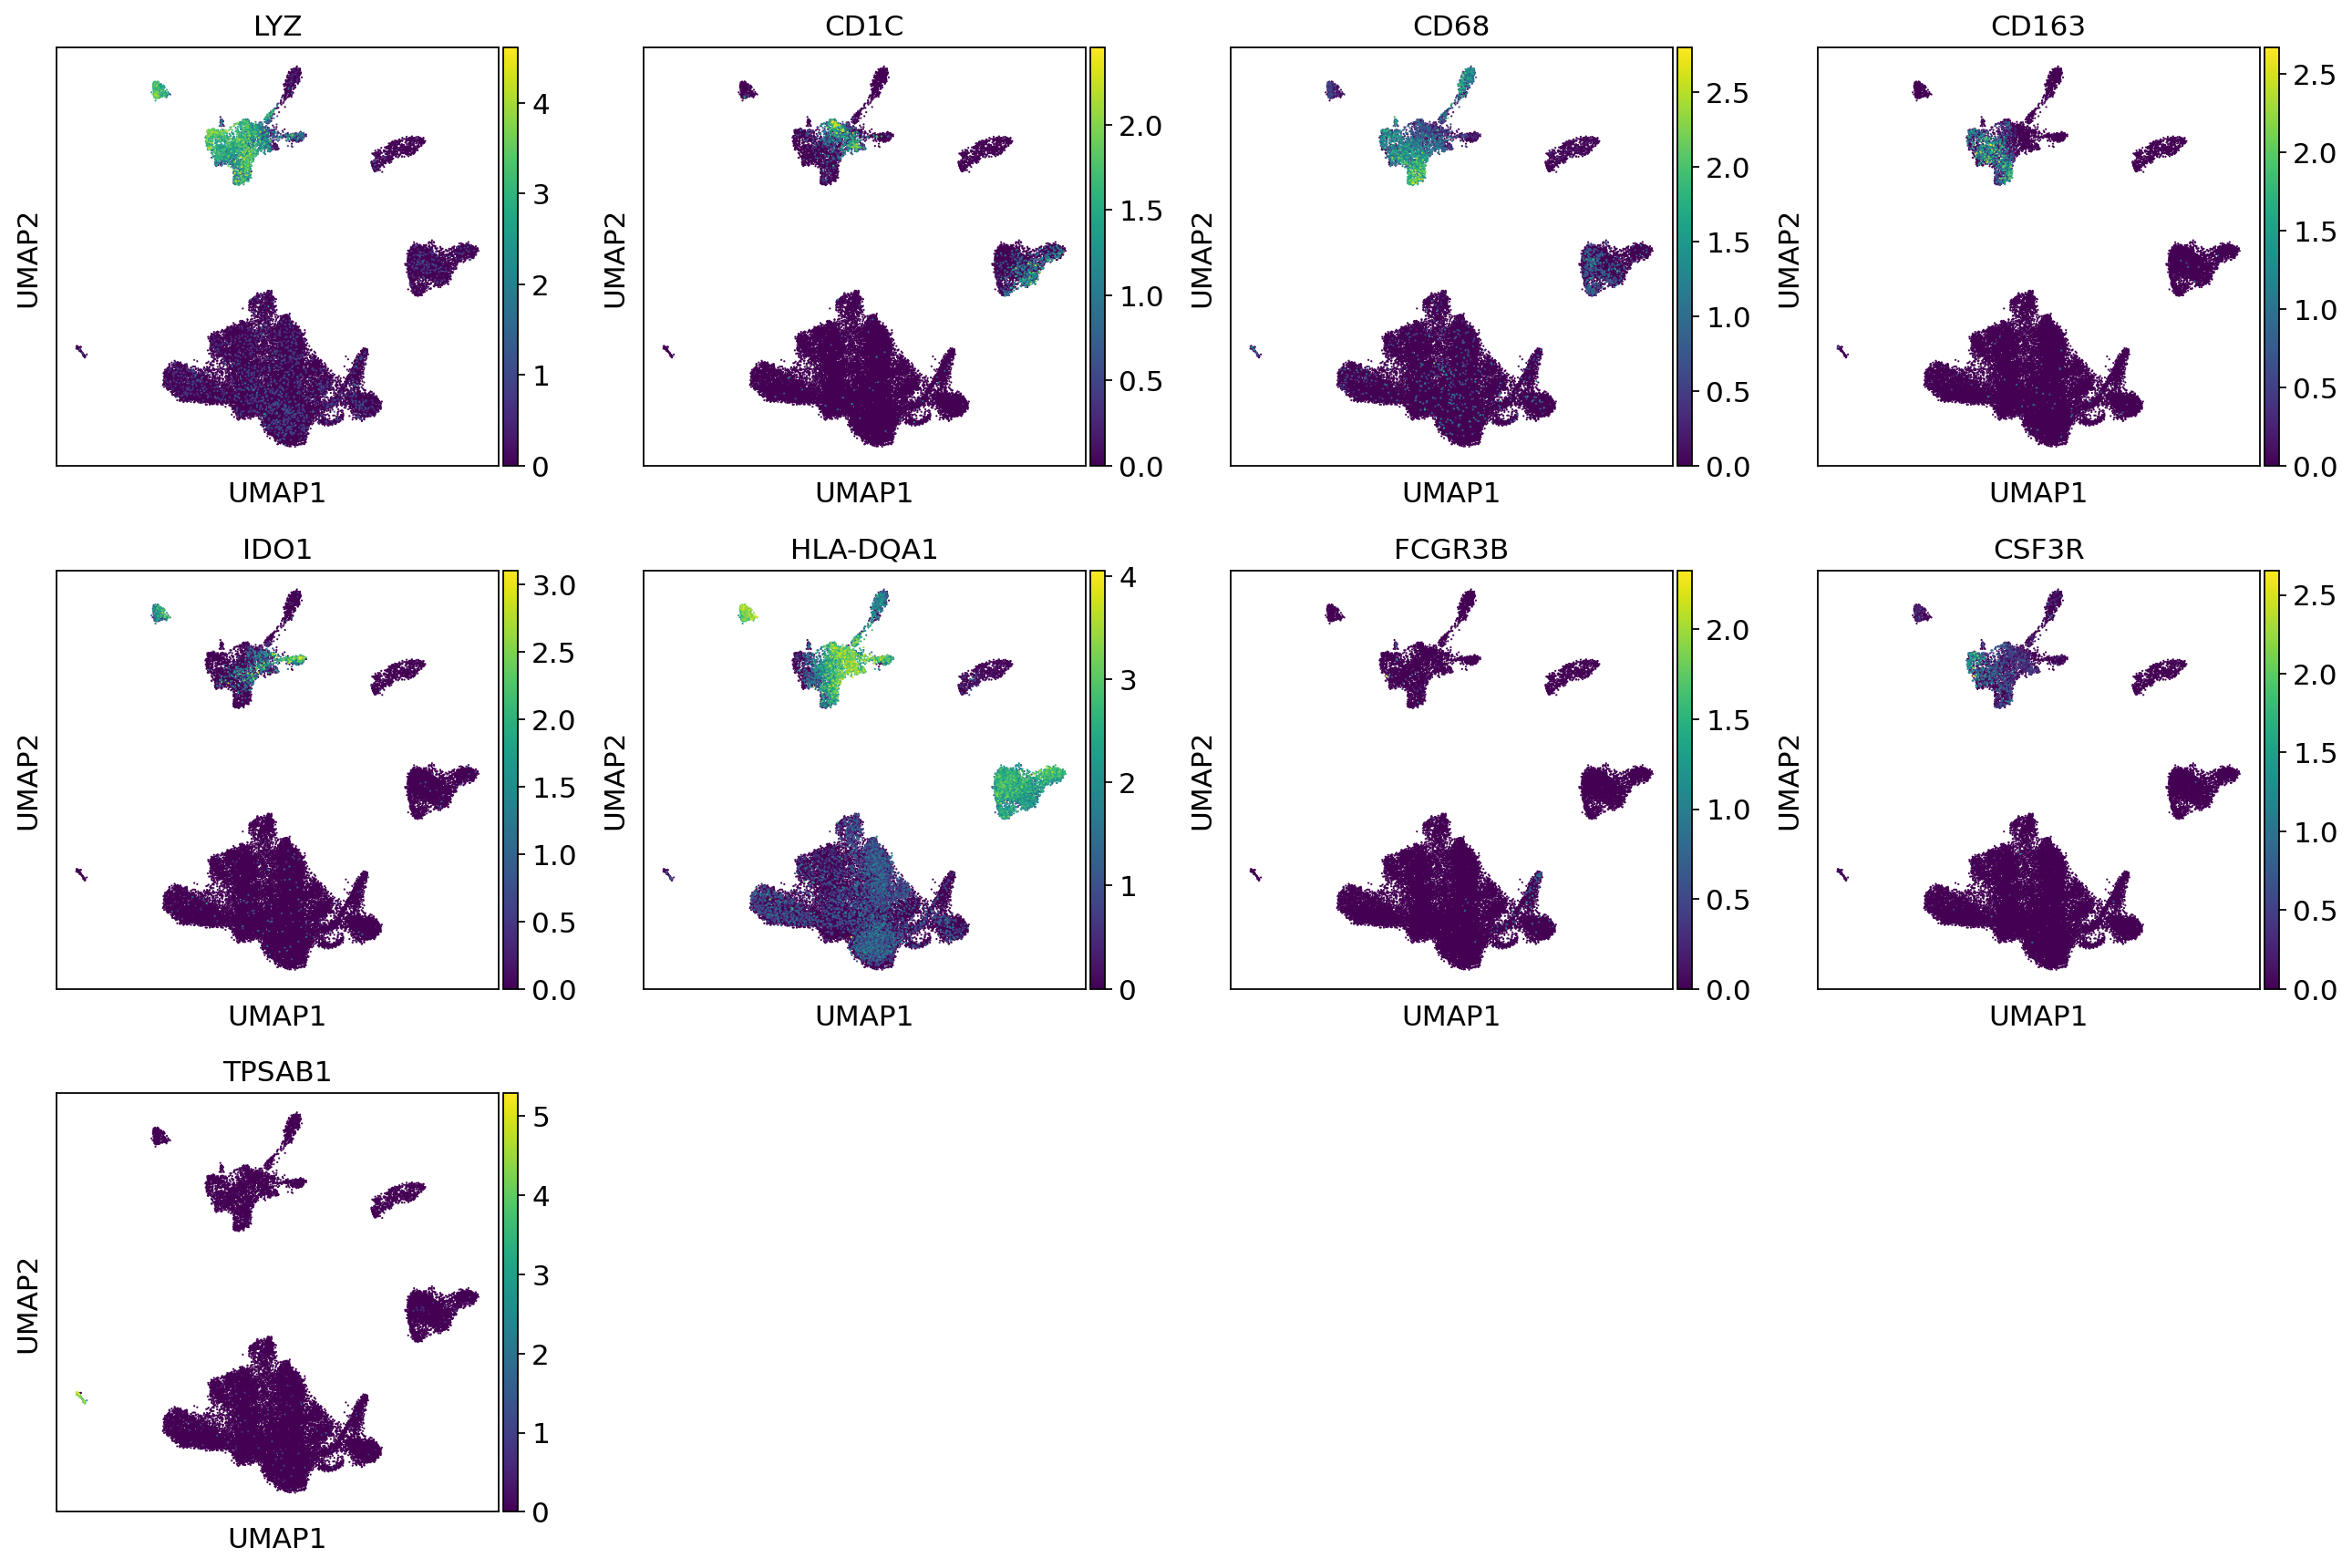

In [19]:
# check annotations
sc.pl.umap(adata, color=['leiden_1','celltype_major','celltype_bped_main'],frameon=False, ncols=2)
sc.pl.umap(adata, color=['CD3D','CD4','CD8A','CD8B','NKG7','GNLY','XCL2','FGFBP2'],frameon=True)
sc.pl.umap(adata, color=['MS4A1','JCHAIN','MZB1','LILRA4'],frameon=True)
sc.pl.umap(adata, color=['LYZ','CD1C','CD68','CD163','IDO1','HLA-DQA1','FCGR3B','CSF3R','TPSAB1'],frameon=True)

In [20]:
adata.obs['celltype_major'].value_counts()

T_cells        20218
Myeloids        3472
B_cells         3251
NK_cells        2556
Plasma           750
pDC              486
Mast              99
Neutrophils        2
Unassigned         1
Name: celltype_major, dtype: int64

In [23]:
# remove ambiguous cells (saved processed_major.h5 before subsetting)
adata = adata[~adata.obs['celltype_major'].isin(['Unassigned','Neutrophils'])]
adata.obs['celltype_major'].value_counts()

T_cells     20218
Myeloids     3472
B_cells      3251
NK_cells     2556
Plasma        750
pDC           486
Mast           99
Name: celltype_major, dtype: int64

In [24]:
adata_counts = adata_counts[adata_counts.obs_names.isin(adata.obs_names)]
adata_counts.obs['celltype_major'] = adata.obs['celltype_major']
adata_counts.obs['celltype_major'].value_counts()

/tmp/ipykernel_572420/3159092252.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_counts.obs['celltype_major'] = adata.obs['celltype_major']


T_cells     20218
Myeloids     3472
B_cells      3251
NK_cells     2556
Plasma        750
pDC           486
Mast           99
Name: celltype_major, dtype: int64

In [25]:
new_categories = ['T_cells', 'NK_cells', 'B_cells','Plasma', 'pDC','Mast','Myeloids']
new_dtype = pd.CategoricalDtype(categories=new_categories, ordered=True)
adata.obs['celltype_major'] = adata.obs['celltype_major'].astype(new_dtype)

/tmp/ipykernel_572420/1831502752.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['celltype_major'] = adata.obs['celltype_major'].astype(new_dtype)


/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


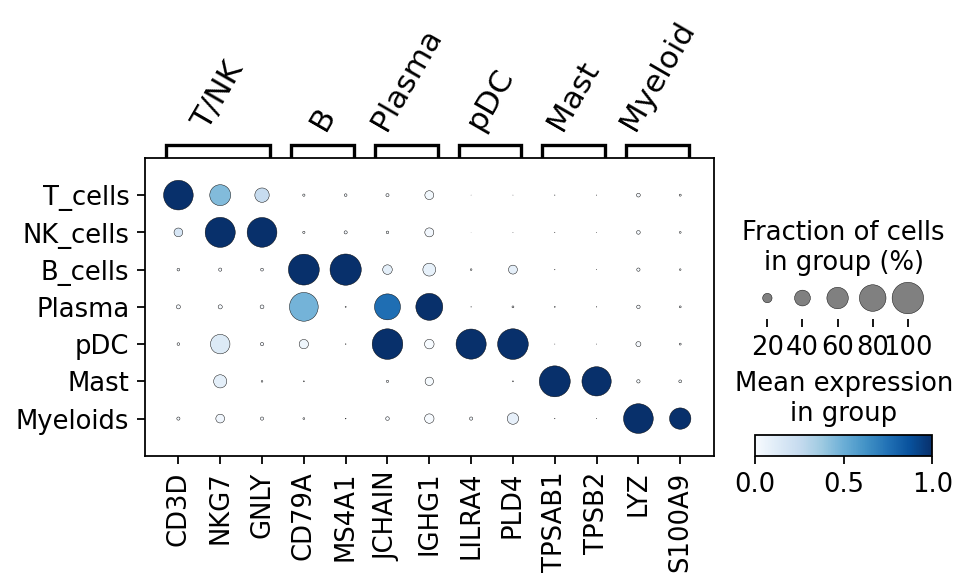

In [29]:
marker_genes_dict = {
    'T/NK': ['CD3D','NKG7','GNLY'],
    'B':['CD79A','MS4A1'],
    'Plasma':['JCHAIN','IGHG1'],
    'pDC':['LILRA4','PLD4'],
    'Mast':['TPSAB1','TPSB2'],
    'Myeloid':['LYZ','S100A9'],
}
sc.pl.dotplot(adata, marker_genes_dict,'celltype_major',cmap='Blues', var_group_rotation=60, standard_scale='var')

In [31]:
# save object
diopy.output.write_h5(adata_counts, file = '/bigdata/zlin/Melanoma_meta/data/HNSC_IMCISION/annotated.h5')